In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

import torch

#Make sure to path to wherever sherlock is located
sys.path.append('../..')
import sherlock as slk

/opt/conda/envs/perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
slk.configs.show()
slk.configs.set_config('ntc_label', 'non-targeting')
print('\n')
slk.configs.show()
slk.configs.reset_config()
slk.configs.get_config('ntc_label')

ntc_label     = NTC
pert_key      = pert
treatment_key = treatment


ntc_label     = non-targeting
pert_key      = pert
treatment_key = treatment


'NTC'

In [ ]:
data = sc.read_h5ad("../../datasets/gbm/preprocessed_cds_without_Tcells.h5ad")

In [5]:
data = data[(data.obs['total_hash_umis_per_cell_ID']>1) & (data.obs['top_to_second_best_ratio']>2)].copy()
data = data[
    (data.obs['total_sgrna_read_per_cell'] > 3)
].copy()
data = data[data.obs['gene_id'] != 'random'].copy()

/var/tmp/ipykernel_2077779/1128722050.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  data.obs.library_size = data.X.sum(axis=1).A1


<Axes: ylabel='Count'>

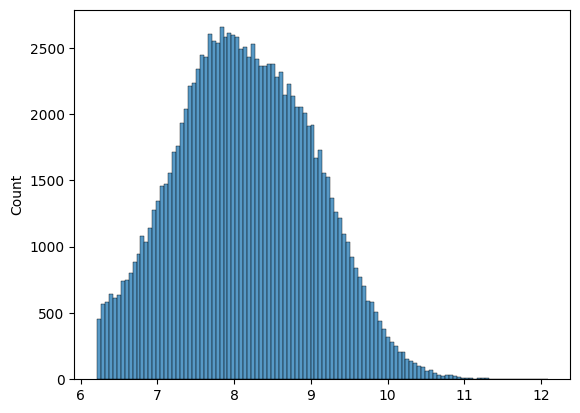

In [6]:
data.obs.library_size = data.X.sum(axis=1).A1
sns.histplot(np.log1p(data.obs.library_size))

<Axes: xlabel='top_proportion', ylabel='Count'>

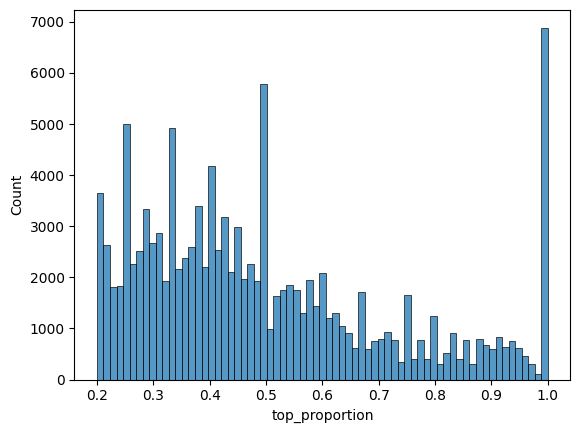

In [7]:
sns.histplot(data.obs.top_proportion)

In [8]:
n = 0.4

before = data.n_obs
mask_keep = data.obs['top_proportion'].notna() & (data.obs['top_proportion'] >= n)
removed = (~mask_keep).sum()
print(f"Filtering out cells with top_proportion < 0.4: removing {removed} cells ({removed/before:.2%})")
data = data[mask_keep].copy()
print(f"After filtering: {data.n_obs} cells remain (was {before})")

Filtering out cells with top_proportion < 0.4: removing 48366 cells (39.92%)
After filtering: 72786 cells remain (was 121152)


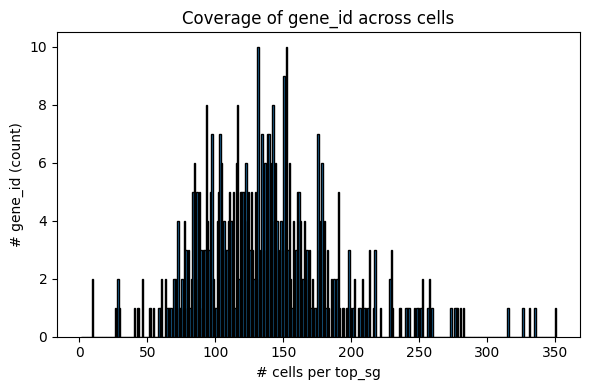

count    522.000000
mean     136.729885
std       50.421466
min        9.000000
25%      103.000000
50%      132.500000
75%      161.000000
max      350.000000
Name: count, dtype: float64


In [9]:
counts = data.obs.loc[data.obs['gene_id'] != 'NTC', 'gene_id'].value_counts()

vals = counts.to_numpy()
bins = np.arange(1, vals.max() + 2)  # integer-width bins starting at 1

plt.figure(figsize=(6,4))
plt.hist(vals, bins=bins, edgecolor='black')
plt.xlabel('# cells per top_sg')
plt.ylabel('# gene_id (count)')
plt.title('Coverage of gene_id across cells')
plt.tight_layout()
plt.show()

print(counts.describe())


In [10]:
# Filter cells whose top_sg has fewer than n cells
n = 100  # set threshold

# guides with count < n (uses existing `counts` Series)
rare_guides = counts[counts < n].index.tolist()

# boolean mask on AnnData obs
mask_rare = data.obs['gene_id'].isin(rare_guides)

print(f"Guides with < {n} cells: {len(rare_guides)}")
print(f"Cells with those guides: {mask_rare.sum()} / {data.n_obs}")

# 2) AnnData with rare-guide cells removed (filtered)
data = data[~mask_rare].copy()

Guides with < 100 cells: 118
Cells with those guides: 9227 / 72786


In [11]:
data.shape

(63559, 56648)

Top 20 guides by mean top_proportion:


,n_cells,mean,median,std,min,max
gene_id,,,,,,
RPS6KA3,175,0.681538,0.636364,0.199789,0.40000,1.0
PIM2,122,0.679635,0.632997,0.195454,0.40000,1.0
PIK3C2B,144,0.676426,0.633929,0.202721,0.40000,1.0
HIPK1,164,0.668956,0.600000,0.204566,0.40000,1.0
TNIK,116,0.668525,0.652586,0.195761,0.40000,1.0
MAPK1,177,0.667178,0.625000,0.205528,0.40000,1.0
PIK3C3,146,0.667057,0.617692,0.192717,0.40146,1.0
FES,119,0.666217,0.600000,0.209813,0.40000,1.0
PAK1,208,0.664483,0.613366,0.205727,0.40000,1.0


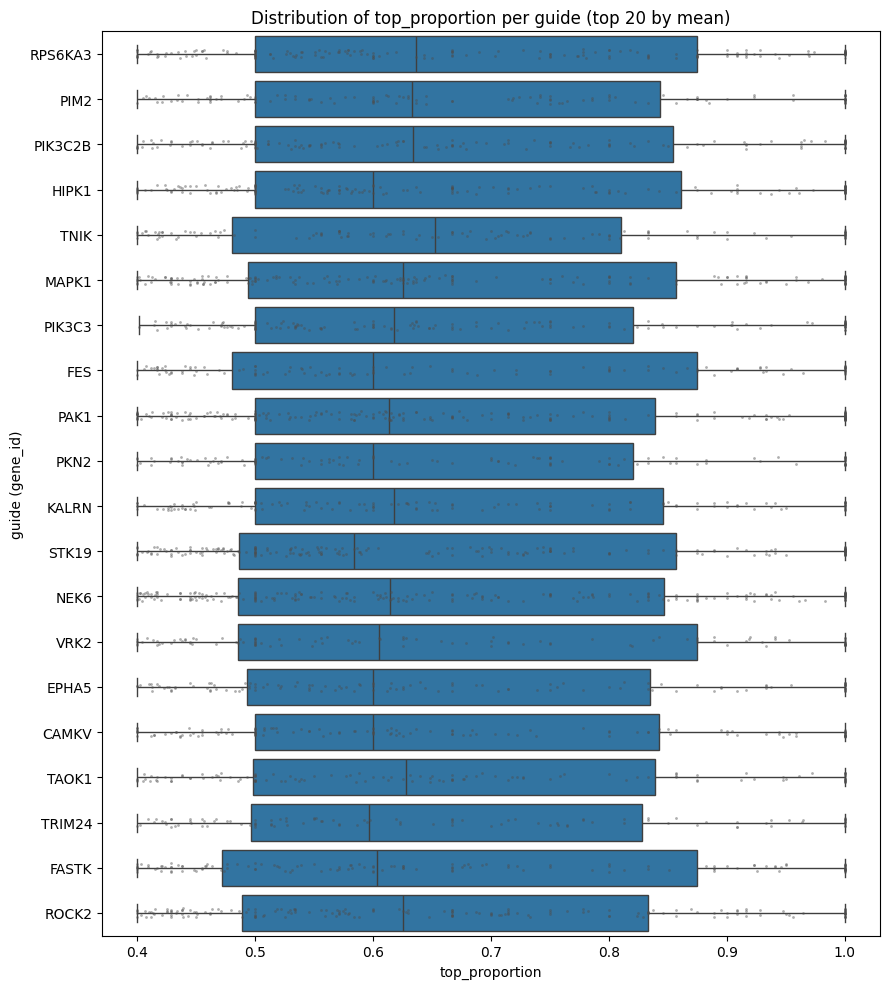

Summary of mean(top_proportion) across all guides:


count    405.000000
mean       0.630596
std        0.016451
min        0.584727
25%        0.618996
50%        0.629692
75%        0.641104
max        0.681538
Name: mean, dtype: float64

In [12]:
# --- params ---
top_n = 20  # how many guides to display

# --- checks & prep ---
assert 'gene_id' in data.obs.columns, "data.obs must contain 'gene_id'"
assert 'top_proportion' in data.obs.columns, "data.obs must contain 'top_proportion'"

# work on a clean frame
df = (
    data.obs[['gene_id', 'top_proportion']]
    .dropna(subset=['gene_id', 'top_proportion'])
    .copy()
)
df['gene_id'] = df['gene_id'].astype(str)

# --- summarize at guide level ---
grp_all = (
    df.groupby('gene_id')['top_proportion']
      .agg(n_cells='count',
           mean='mean',
           median='median',
           std='std',
           min='min',
           max='max')
      .sort_values('mean', ascending=False)
)

# --- choose top_n guides by mean top_proportion ---
top_n = int(top_n)
top_guides = grp_all.head(top_n).index.tolist()

print(f"Top {min(top_n, len(grp_all))} guides by mean top_proportion:")
display(grp_all.head(top_n))

# --- subset observations for plotting ---
sub_top = df[df['gene_id'].isin(top_guides)].copy()

# ensure y-axis order matches descending mean from grp_all
order = [g for g in grp_all.index if g in top_guides]

# --- plot: distribution of top_proportion per top_sg ---
plt.figure(figsize=(9, max(6, 0.35 * len(order) + 3)))
sns.boxplot(
    data=sub_top, x='top_proportion', y='gene_id',
    order=order, showfliers=False
)
sns.stripplot(
    data=sub_top, x='top_proportion', y='gene_id',
    order=order, size=2, jitter=True, alpha=0.45, color='0.3'
)
plt.xlabel('top_proportion')
plt.ylabel('guide (gene_id)')
plt.title(f'Distribution of top_proportion per guide (top {len(order)} by mean)')
plt.tight_layout()
plt.show()

# --- optional: quick summary on spread of means (useful sanity check) ---
print("Summary of mean(top_proportion) across all guides:")
display(grp_all['mean'].describe())


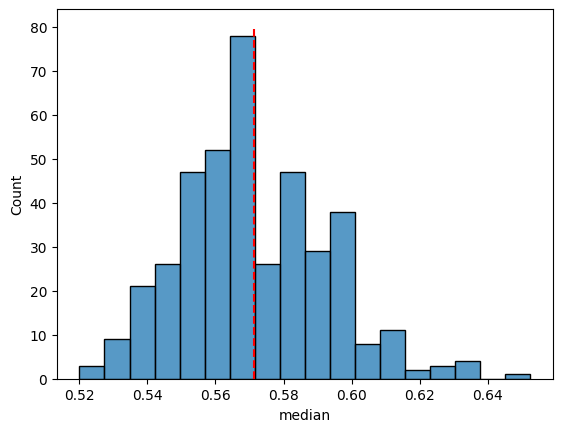

In [13]:
sns.histplot(grp_all['median'])
plt.vlines(grp_all['median'].median(), ymin=0, ymax=80, colors='red', linestyles='dashed')

In [14]:
n = 0.56

low_median_guides = grp_all[grp_all['median'] < n].index.astype(str).tolist()
print(f"Guides with median(top_proportion) < {n}: {len(low_median_guides)}")

# boolean mask for cells whose top_sg is in the low-median guide list
mask_low_median = data.obs['gene_id'].astype(str).isin(low_median_guides)
print(f"Cells to remove: {mask_low_median.sum()} / {data.n_obs}")

# filter the AnnData object (keep cells NOT in low_median_guides)
data = data[~mask_low_median].copy()
print(f"After filtering: {data.n_obs} cells remain")

Guides with median(top_proportion) < 0.56: 126
Cells to remove: 19073 / 63559
After filtering: 44486 cells remain


In [15]:
data.obs.gene_id.nunique()

279

<Axes: ylabel='Count'>

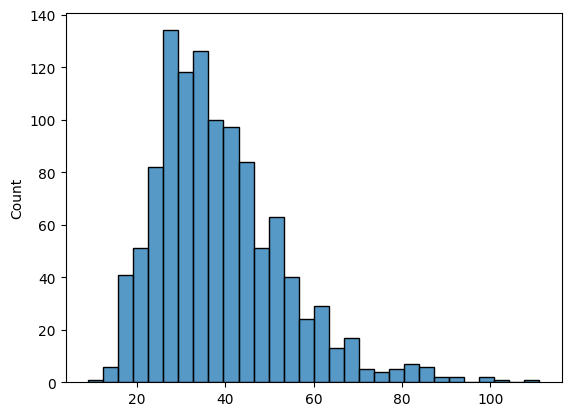

In [16]:
# create a table of counts: rows = perturbation (gene_id), cols = dosage, values = # occurrences
obs_df = data.obs[['gene_id', 'dose']].dropna().copy()
obs_df['gene_id'] = obs_df['gene_id'].astype(str)

# simple cross-tab
perturbation_by_dosage = pd.crosstab(obs_df['gene_id'], obs_df['dose'])

# try to order dosage columns numerically if possible
try:
    dos_numeric = pd.to_numeric(perturbation_by_dosage.columns, errors='coerce')
    if dos_numeric.notna().all():
        ordered_cols = perturbation_by_dosage.columns[dos_numeric.argsort()]
        perturbation_by_dosage = perturbation_by_dosage[ordered_cols]
except Exception:
    pass

# sort rows by total counts (descending)
perturbation_by_dosage = (
    perturbation_by_dosage
    .assign(_total=perturbation_by_dosage.sum(axis=1))
    .sort_values('_total', ascending=False)
    .drop(columns='_total')
)

sns.histplot(perturbation_by_dosage.to_numpy().flatten()[4:])

In [17]:
n_min = 30  # require each dose column to have at least n_min cells

# keep rows only if every dose column meets the threshold
keep_rows = (perturbation_by_dosage >= n_min).all(axis=1)
perturbation_by_dosage_filt = perturbation_by_dosage.loc[keep_rows].copy()

valid_gene_ids = set(perturbation_by_dosage_filt.index.astype(str))

mask = data.obs['gene_id'].astype(str).isin(valid_gene_ids)
data = data[mask].copy()

print(f"Kept {keep_rows.sum()} perturbations (each dose >= {n_min}) out of {len(keep_rows)}.")
print(f"Cells kept: {mask.sum()} / {data.n_obs} ({mask.mean():.1%})")
print("Filtered crosstab shape:", perturbation_by_dosage_filt.shape)
print("Filtered AnnData shape:", data.shape)


Kept 94 perturbations (each dose >= 30) out of 279.
Cells kept: 19923 / 19923 (44.8%)
Filtered crosstab shape: (94, 4)
Filtered AnnData shape: (19923, 56648)


In [18]:
counter = 0
sum_ = 0
for i in data.obs.gene_id:
    if i != "NTC":
        sum_ += 1
    if i in data.var_names and i != 'NTC':
        counter += 1
print(counter/sum_)

0.971690977849811


In [19]:
control_data = data[data.obs.dose==0].copy()

sc.pp.normalize_total(control_data)
sc.pp.log1p(control_data)
sc.pp.pca(control_data)

sc.tl.rank_genes_groups(
    control_data, groupby='gene_id', reference='NTC',
    use_raw=False, method='wilcoxon'
)

/opt/conda/envs/perturb/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/opt/conda/envs/perturb/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/opt/conda/envs/perturb/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:463: PerformanceWarning: DataFrame is highly 

In [20]:
# Long-form results across all groups
df = sc.get.rank_genes_groups_df(control_data, group=None, key='rank_genes_groups')

# Raw p-value < 0.05
sig_raw = (df.loc[df['pvals'] < 0.05]
             .sort_values(['group','pvals'])
             .reset_index(drop=True))

# Adjusted p-value (FDR) < 0.05 (recommended)
sig_adj = (df.loc[df['pvals_adj'] < 0.05]
             .sort_values(['group','pvals_adj'])
             .reset_index(drop=True))

# Per-group lists (raw p)
deg_by_group_raw = (sig_raw.groupby('group')['names'].apply(list).to_dict())

# Per-group lists (FDR)
deg_by_group_adj = (sig_adj.groupby('group')['names'].apply(list).to_dict())

# Unique gene sets
unique_deg_raw = sorted(sig_raw['names'].unique().tolist())
unique_deg_adj = sorted(sig_adj['names'].unique().tolist())

print("\nCounts (FDR<0.05) per group:")
print(sig_adj.groupby('group').size())


Counts (FDR<0.05) per group:
group
AATK      0
AKT1      0
ALPK3     0
CAMK1D    0
CAMK1G    0
         ..
UHMK1     0
VRK1      0
WNK4      0
ZAK       0
ZAP70     0
Length: 93, dtype: int64


/var/tmp/ipykernel_2077779/3292257313.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  deg_by_group_raw = (sig_raw.groupby('group')['names'].apply(list).to_dict())
/var/tmp/ipykernel_2077779/3292257313.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  deg_by_group_adj = (sig_adj.groupby('group')['names'].apply(list).to_dict())
/var/tmp/ipykernel_2077779/3292257313.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

In [21]:
deg_genes = df[df['pvals'] < 0.05]['names'].unique()

In [22]:
sc.pp.highly_variable_genes(
    data,
    flavor='seurat_v3',
    n_top_genes=2000
)

In [24]:
data.obs.gene_id.unique()

array(['NTC', 'SPEG', 'CDK6', 'PDK2', 'LMTK2', 'RPS6KA3', 'RPS6KL1',
       'RPS6KA6', 'TBK1', 'LIMK1', 'MOK', 'GUCY2F', 'RPS6KA1', 'MAPK1',
       'MST4', 'STK11', 'TNK2', 'CAMK1D', 'AATK', 'MAPK13', 'UHMK1',
       'RIOK3', 'ALPK3', 'MAPK3', 'GSK3A', 'PAK6', 'MYLK', 'FYN', 'PKN1',
       'GSK3B', 'TTN', 'MARK2', 'STK17B', 'MAPKAPK5', 'MERTK', 'GRK7',
       'HIPK3', 'STK32C', 'CLK3', 'SLK', 'PASK', 'WNK4', 'SGK1', 'PLK2',
       'ROCK1', 'NEK7', 'IGF1R', 'RET', 'LATS2', 'NEK10', 'LMTK3', 'NEK6',
       'PAK1', 'MAP3K4', 'TAOK3', 'ROCK2', 'NIM1', 'MAP3K13', 'TRIM28',
       'FER', 'PTK7', 'CAMK1G', 'CDK9', 'EPHA4', 'MAP3K12', 'DYRK3',
       'SIK1', 'ZAP70', 'TRPM7', 'SIK2', 'PIK3C2B', 'MKNK1', 'STK38',
       'AKT1', 'PIM3', 'PRKCZ', 'TXK', 'RIPK1', 'MAST1', 'ZAK', 'VRK1',
       'MAPK6', 'STK4', 'CDC42BPB', 'CDKL3', 'STK10', 'NUAK1', 'RPS6KA2',
       'ERBB4', 'STK19', 'PIM1', 'PRKCQ', 'PINK1', 'STK40'], dtype=object)

In [ ]:
import pyreadr
result = pyreadr.read_r('../../datasets/gbm/KinMap_kinase_protein_to_gene_map.rds')
res = result[None]  # RDS files contain only one object, so we use None as key
res = res[res['gene_id'].isin(data.obs.gene_id.unique())]
kinase_names = res['gene_short_name']

In [29]:
hv_mask = data.var['highly_variable']
hv_genes = np.array(data.var_names)[np.asarray(hv_mask).astype(bool)]

# make sets (cast to str to avoid dtype issues)
hv_set = set(map(str, hv_genes))
deg_set = set(map(str, deg_genes))
kinase_set = set(map(str, kinase_names))

union_set = hv_set | deg_set | kinase_set
union_list = sorted(union_set)

print(f"highly_variable: {len(hv_set)} genes")
print(f"deg_genes:        {len(deg_set)} genes")
print(f"kinase_genes:     {len(set(kinase_names))} genes")
print(f"union:            {len(union_set)} genes")

highly_variable: 2000 genes
deg_genes:        3157 genes
kinase_genes:     93 genes
union:            5066 genes


In [32]:
data = data[:, union_list].copy()

In [33]:
counter = 0
sum_ = 0
for i in data.obs.gene_id:
    if i != "NTC":
        sum_ += 1
    if i in data.var_names and i != 'NTC':
        counter += 1
print(counter/sum_)

0.971690977849811


In [40]:
data.var.rename(columns={'_index':'index'},inplace=True)
data.raw.var.rename(columns={'_index':'index'},inplace=True)

In [ ]:
data.write_h5ad("../../datasets/gbm/top100_cripsri_gbm.h5ad")

In [42]:
data.shape

(19923, 5066)

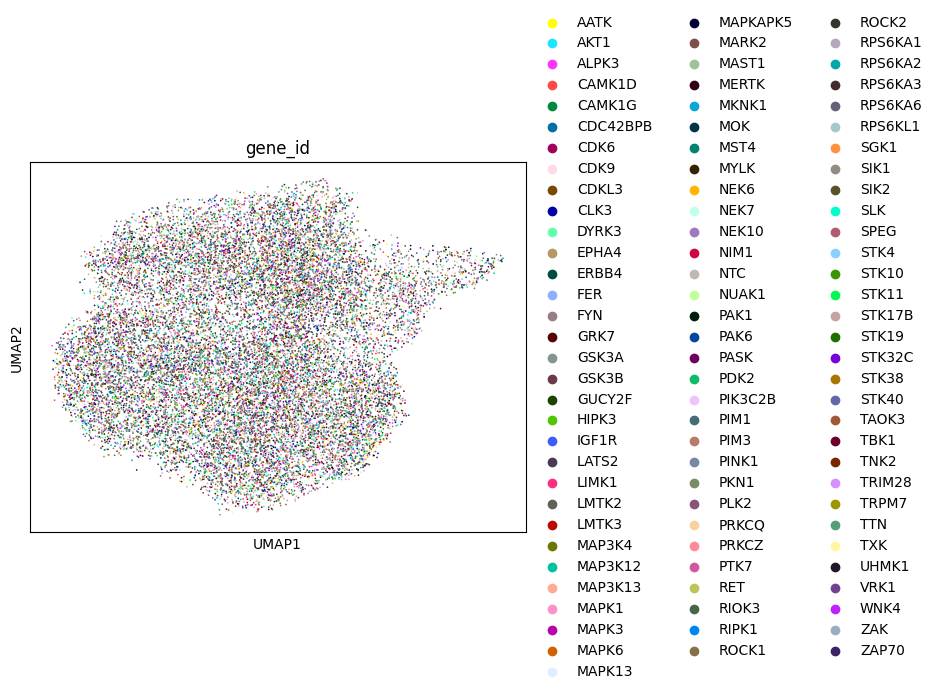

In [44]:
sc.pp.normalize_total(data)
sc.pp.log1p(data)
sc.pp.pca(data)

sc.pp.neighbors(data)
sc.tl.umap(data)
sc.pl.umap(data, color=['gene_id'])

In [46]:
data.obs.dose = data.obs.dose.astype(str)

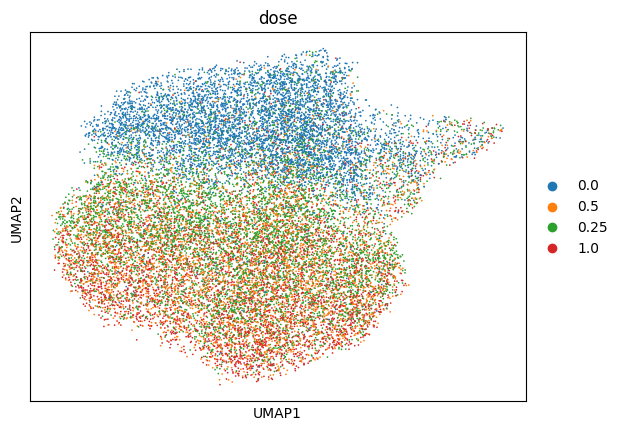

In [47]:
sc.pl.umap(data, color=['dose'])